# OLS Regression

**Name:** Jakkarin Promsee <br/>
**Student ID:** 67070501009 

## Problem

You are provided with a dataset containing the information about a small business's monthly advertising expenditure and corresponding sales. The dataset includes the following variables:

- **Advertising Budget ($X$)**: the amount spent on advertising, in **thousands of dollars**
- **Sales ($Y$)**: the number of units sold, in **thousands**

| Month | Advertising Budget ($X$) | Sales ($Y$) |
| --- | --- | --- |
| 1 | 3.0 | 6.0 |
| 2 | 5.0 | 9.0 |
| 3 | 2.0 | 4.0 |
| 4 | 7.0 | 10.0 |
| 5 | 8.0 | 12.0 |
| 6 | 1.0 | 3.0 |
| 7 | 4.0 | 7.0 |
| 8 | 6.0 | 8.0 |
| 9 | 9.0 | 13.0 |
| 10 | 10.0 | 15.0 |

In [22]:
import numpy as np

In [23]:
# Problem
x = np.array([3., 5., 2., 7., 8., 1., 4., 6., 9., 10.])
y = np.array([6., 9., 4., 10., 12., 3., 7., 8., 13., 15.])


In [24]:
# Check the amount of dataset
n = len(x)
print(f"n = {n}")

n = 10


## Task 1 Implement OLS Regression

### Method 1: Using the OLS method


Fit $\hat{y}=\alpha+\beta x$ 

$$\hat\beta = \frac{\sum (x_i-\bar{x})(y_i-\bar{y})}{\sum (x_i-\bar{x})^2}, \qquad \hat\alpha=\bar y-\hat\beta\bar x$$


In [25]:
# Compute mean value
x_bar = np.mean(x)
y_bar = np.mean(y)

# Compute different value from mean
dx = x - x_bar
dy = y - y_bar

# Sum( (x_i - x_bar)(y_i - y_bar) )
s_xy = np.sum(dx * dy)

# Sum(x_i - x_bar)^2
s_xx = np.sum(dx ** 2)

# Final formular
beta = s_xy / s_xx
alpha = y_bar - beta * x_bar


In [26]:
print(f"x_bar = {x_bar}     y_bar = {y_bar}")
print(f"S_xy = {s_xy}      S_xx = {s_xx}")
print(f"intercept = {alpha:.4f}")
print(f"slope = {beta:.4f}")

x_bar = 5.5     y_bar = 8.7
S_xy = 104.5      S_xx = 82.5
intercept = 1.7333
slope = 1.2667


### Method 2: using matrix normal equation (optional)

In [27]:
# matrix A -> [[1, x_1], [1, x_2], [1, x_3], ... ]
# [1, ...] is alpha term, while [..., x_1] is beta term
# n = 10
A = np.column_stack((np.ones(n), x))

# Pseudo-inverse -> AB = y -> B = A* y
B = np.linalg.pinv(A) @ y

In [28]:
print("A.shape =", A.shape)
print(f"B = {B}")
print(f"intercept = {B[0]:.4f}")
print(f"slope = {B[1]:.4f}")


A.shape = (10, 2)
B = [1.73333333 1.26666667]
intercept = 1.7333
slope = 1.2667


### Summary (Final Answer)

$\hat\alpha = 1.7333$ and $\hat\beta = 1.2667$.

$$\hat{y} = 1.7333 + 1.2667x$$


## Task 2 — Interpret the Results


In [29]:
x_new = 12.0
y_new = alpha + beta * x_new

In [30]:
print(f"budget = ${x_new * 1000:,.0f}")
print(f"predicted sales = {y_new:.4f} thousand units = {y_new * 1000:,.0f} units")

budget = $12,000
predicted sales = 16.9333 thousand units = 16,933 units


#### Explain the meaning of the slope and intercept in the context of this problem.

**Slope:** ($\hat\beta = 1.2667$): For every additional $1,000 spent on advertising (X), the model predicts sales to increase by about 1.2667 thousand units (Y).

**Intercept:** ($\hat\alpha = 1.7333$): When advertising spending between 0 (X), the model predicts about 1.7333 thousand units sold (Y).  It remains constant and does not change along with advertising (X). 

**Limitation:** this is the observed range of X (1 to 10), The Outside the range of 1 to 10 isn't promise.

#### Predict the sales if the advertising budget is $12,000.

At $x=12$ (thousand units), the predicted sales are about 16.9333 thousand units, or about 16,933 units. This is an extrapolation because 12 is outside the observed range.

## Task 3 — Model Evaluation

$$R^2=1-\frac{SS_{res}}{SS_{tot}}$$


In [31]:
# Predict value
y_hat = alpha + beta * x

# Our model predict score
ss_res = np.sum((y - y_hat) ** 2)

# Average predict score
ss_tot = np.sum((y - y_bar) ** 2)

# r square compute
r2 = 1 - ss_res / ss_tot

In [32]:
print(f"SS_res = {ss_res:.4f}")
print(f"SS_tot = {ss_tot:.4f}")
print(f"R^2 = {r2:.4f}")

SS_res = 3.7333
SS_tot = 136.1000
R^2 = 0.9726


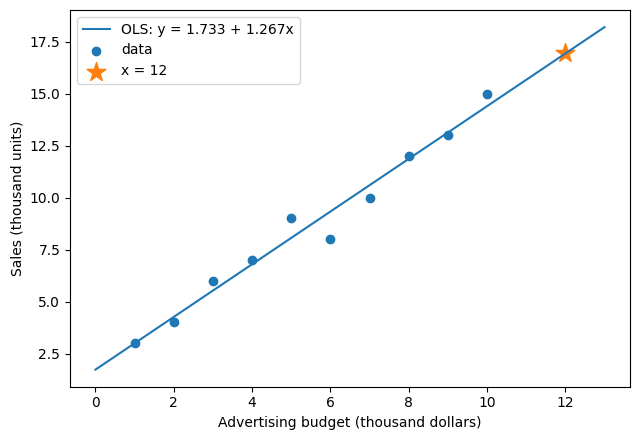

In [33]:
import matplotlib.pyplot as plt

grid = np.linspace(x.min() - 1, x_new + 1, 100)
plt.figure(figsize=(6.5, 4.5))
plt.plot(grid, alpha + beta * grid, label=f"OLS: y = {alpha:.3f} + {beta:.3f}x")
plt.scatter(x, y, label="data")
plt.scatter([x_new], [y_new], marker="*", s=200, label="x = 12")
plt.xlabel("Advertising budget (thousand dollars)")
plt.ylabel("Sales (thousand units)")
plt.legend()
plt.tight_layout()
plt.show()


#### Provide a brief interpretation of the R-squared value obtained.

$R^2 = 0.9726$ means that roughly 97.26% of the variation in sales can be explained by the advertising budget, which indicates a strong fit for the model. The remaining ~3% comes from other unmeasured factors or random noise. <br/>

Keep in mind that a high $R^2$ shows a strong correlation, but it doesn't prove that advertising directly causes the increase in sales. 
